# HFA PSTH — Whole-Trial Course

Single-purpose notebook: compute baseline-z-scored HFA per channel, then plot
event-aligned PSTHs (per-channel trial-averages) for each brain region.

**Layout:** rows = brain regions, columns = three trial events:
1. Encoding 1 onset, window (-1, 2) s
2. Maintenance (delay) onset, window (0, 2.5) s
3. Probe onset, window (0, 2) s

**Per panel:** thin gray lines = per-channel trial-mean HFA; bold colored line =
mean across channels with ± SEM band. All trials are pooled together per channel.
No condition split. No artifact-channel exclusion.

## 1. Setup & Config

In [ ]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats as scistats
from scipy.signal import butter, filtfilt, hilbert, detrend

from pynwb import NWBHDF5IO

from nwb_analysis.data_loading import get_subject_files, load_nwb_file, load_lfp_safe
from nwb_analysis.regions import extract_region_channels
from nwb_analysis.config import BRAIN_REGIONS

plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})
warnings.filterwarnings('ignore', category=RuntimeWarning)
warnings.filterwarnings('ignore', category=UserWarning, module='pynwb')

In [65]:
PROJECT_ROOT = Path('.').resolve()
DATA_DIR = PROJECT_ROOT.parent / 'data' / '000673'
OUT_DIR = PROJECT_ROOT / 'outputs' / 'hfa_psth_whole_trial'
OUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'data_dir': DATA_DIR,
    'random_seed': 20260507,

    # Session selection — picks passing.iloc[SESSION_INDEX] later.
    'session_index': 5,
    'min_chans_per_region': 8,   # softer than the CSA notebook so every region with
                                 # at least 4 channels gets a row.

    # Bundle CAR settings (line-noise notch is skipped: raw data already cleaned upstream)
    'assume_already_referenced': True,
    'bundle_field_candidates': ['group_name', 'group', 'bundle'],

    # HFA extraction — only need band edges + how many sub-bands
    'hfa_band_low':2.0,         # lowest edge of lowest sub-band (Hz)
    'hfa_band_high': 14.0,       # highest edge of highest sub-band (Hz)
    'hfa_n_subbands': 1,          # contiguous, equal-width sub-bands
    'hfa_filter_order': 4,
    'hfa_baseline_window': (-1.0, 0.0),         # relative to encoding1 onset
    'hfa_baseline_lock_event': 'encoding1',
    'hfa_baseline_bootstrap_iters': 100,    # 100 is plenty given the ~54k-sample baseline pool

    # Trial filtering
    'use_only_correct': True,

    # PSTH events: (lock_event, window_seconds)
    'psth_events': {
        'encoding1':   (-1.0, 2.0),
        'maintenance': (0.0,  2.5),
        'probe':       (0.0,  2.0),
    },

    # Regions to plot (all 5 default-mapped regions)
    'psth_regions': ['Hippocampus', 'Amygdala', 'vmPFC', 'dACC', 'preSMA'],
}

# Resolve sub-band edges + centers from (band_low, band_high, n_subbands)
_edges = np.linspace(CONFIG['hfa_band_low'], CONFIG['hfa_band_high'], CONFIG['hfa_n_subbands'] + 1)
CONFIG['hfa_subband_edges']   = list(zip(_edges[:-1], _edges[1:]))
CONFIG['hfa_subband_centers'] = (_edges[:-1] + _edges[1:]) / 2

print('events:', list(CONFIG['psth_events']))
print('regions:', CONFIG['psth_regions'])
print('out dir:', OUT_DIR)

events: ['encoding1', 'maintenance', 'probe']
regions: ['Hippocampus', 'Amygdala', 'vmPFC', 'dACC', 'preSMA']
out dir: E:\SBCAT\outputs\hfa_psth_whole_trial


## 2. Helpers (preprocessing + HFA + epoching)

In [50]:
# --- Preprocessing helpers (no line-noise notch; raw data already cleaned) ---
def detect_bundles(edf, candidate_fields):
    for field in candidate_fields:
        if field not in edf.columns:
            continue
        labels = edf[field].astype(str)
        if labels.nunique() > 1 and (labels.value_counts() > 1).any():
            return labels
    if 'location' in edf.columns:
        return edf['location'].astype(str)
    return None


def bundle_local_reference(lfp, bundle_labels, channel_indices):
    out = lfp.copy()
    sub_labels = bundle_labels.loc[channel_indices]
    for bundle, group in sub_labels.groupby(sub_labels):
        idx = group.index.tolist()
        if len(idx) < 2:
            continue
        bundle_mean = lfp[:, idx].mean(axis=1, keepdims=True)
        out[:, idx] = lfp[:, idx] - bundle_mean
    return out


def load_lfp_oriented(lfp_series, n_electrodes):
    """Return LFP as (timepoints, channels), auto-correcting transposition."""
    raw = np.asarray(lfp_series.data)
    if raw.ndim == 1:
        return raw.reshape(-1, 1)
    s0, s1 = raw.shape
    if s0 == n_electrodes and s1 != n_electrodes:
        print(f'  [transpose] LFP loaded as (chan, time)={raw.shape}; transposing to (time, chan)')
        return raw.T
    return raw


def preprocess_session_lfp(nwb_data, cfg, verbose=True):
    lfp_series = nwb_data['lfp']['series']
    fs = nwb_data['lfp']['sampling_rate']
    edf = nwb_data['electrodes']
    n_electrodes = len(edf)

    lfp = load_lfp_oriented(lfp_series, n_electrodes).astype(np.float32)
    n_chan_lfp = lfp.shape[1]
    if verbose:
        print(f'  loaded LFP: shape={lfp.shape}, fs={fs}, n_electrodes_in_table={n_electrodes}')
    if n_chan_lfp != n_electrodes:
        print(f'  [warn] LFP has {n_chan_lfp} channels but electrodes table has {n_electrodes} '
              f'rows; channels with idx >= {n_chan_lfp} will be dropped downstream')

    lfp = lfp - lfp.mean(axis=0, keepdims=True)
    lfp = detrend(lfp, axis=0, type='linear')

    if cfg['assume_already_referenced']:
        if verbose:
            print('  [skip] bundle re-reference')
        bundle_labels = None
    else:
        bundle_labels = detect_bundles(edf, cfg['bundle_field_candidates'])
        if bundle_labels is None:
            print('  [warn] no bundle field; skipping local re-reference')
        else:
            valid = list(range(n_chan_lfp))
            if verbose:
                print(f'  bundle CAR using {bundle_labels.nunique()} bundles (over {len(valid)} LFP channels)')
            lfp = bundle_local_reference(lfp, bundle_labels.iloc[:n_chan_lfp], valid)
    return lfp, fs, edf, {'bundle_labels': bundle_labels, 'n_chan_lfp': n_chan_lfp}


print('preprocessing helpers defined')


preprocessing helpers defined


In [51]:
# --- HFA + epoching helpers ---
def design_subband_filter(fs, low, high, order):
    nyq = fs / 2
    return butter(order, [low / nyq, high / nyq], btype='band')


def subband_envelopes(lfp_chan, fs, edges, order):
    out = np.empty((len(edges), lfp_chan.shape[0]), dtype=np.float32)
    for i, (lo, hi) in enumerate(edges):
        b, a = design_subband_filter(fs, lo, hi, order)
        bp = filtfilt(b, a, lfp_chan)
        out[i] = np.abs(hilbert(bp)).astype(np.float32)
    return out


def bootstrap_baseline_zscore(envelope, baseline_idx, n_iters, rng):
    """Vectorized bootstrap baseline z-score.

    Draws n_iters resamples (size = baseline pool size) in one numpy op,
    averages per-resample means and SDs, then z-scores the full envelope.
    No Python for-loop -> ~30x faster, GIL-released throughout.
    """
    base_vals = envelope[baseline_idx]
    if base_vals.size == 0:
        return np.zeros_like(envelope)
    n = base_vals.size
    if n < 2:
        return envelope - base_vals.mean()
    # (n_iters, n) bootstrap-index matrix; ~22 MB for n_iters=100, n=54k float32
    idx = rng.integers(0, n, size=(n_iters, n))
    samples = base_vals[idx]
    mu = samples.mean(axis=1).mean()
    sigma = samples.std(axis=1, ddof=1).mean()
    if sigma <= 0:
        sigma = base_vals.std(ddof=1) + 1e-12
    return (envelope - mu) / sigma


_LOCK_COL_MAP = {
    'fixation':    'timestamps_FixationCross',
    'encoding1':   'timestamps_Encoding1',
    'encoding2':   'timestamps_Encoding2',
    'encoding3':   'timestamps_Encoding3',
    'maintenance': 'timestamps_Maintenance',
    'probe':       'timestamps_Probe',
    'response':    'timestamps_Response',
}


def collect_baseline_indices(trial_table, fs, lock_event, baseline_window, lfp_n_samples):
    col = _LOCK_COL_MAP[lock_event]
    starts = trial_table[col].to_numpy()
    starts = starts[starts > 0]
    pre, post = baseline_window
    pre_n = int(round(pre * fs)); post_n = int(round(post * fs))
    all_idx = []
    for t in starts:
        center = int(round(t * fs))
        s = center + pre_n; e = center + post_n
        if s < 0 or e > lfp_n_samples or s >= e:
            continue
        all_idx.append(np.arange(s, e))
    if not all_idx:
        return np.array([], dtype=int)
    return np.concatenate(all_idx)


def extract_hfa_session(lfp_clean, fs, channel_indices, trial_table, cfg, rng):
    edges = cfg['hfa_subband_edges']
    baseline_idx = collect_baseline_indices(
        trial_table, fs, cfg['hfa_baseline_lock_event'], cfg['hfa_baseline_window'], lfp_clean.shape[0]
    )
    if baseline_idx.size == 0:
        raise ValueError('empty baseline index set; check lock_event timestamps in trials table')
    n_chan = len(channel_indices)
    T = lfp_clean.shape[0]
    hfa = np.empty((n_chan, T), dtype=np.float32)
    for ci, c in enumerate(channel_indices):
        envs = subband_envelopes(lfp_clean[:, c], fs, edges, cfg['hfa_filter_order'])
        z_envs = np.empty_like(envs)
        for sb in range(envs.shape[0]):
            z_envs[sb] = bootstrap_baseline_zscore(
                envs[sb], baseline_idx, cfg['hfa_baseline_bootstrap_iters'], rng,
            )
        hfa[ci] = z_envs.mean(axis=0)
    return hfa, baseline_idx


def epoch_continuous(continuous, fs, lock_times, window):
    """Cut a (n_chan, T) array into (n_trials, n_chan, n_t) at lock_times +/- window."""
    pre, post = window
    pre_n = int(round(pre * fs)); post_n = int(round(post * fs))
    n_t = post_n - pre_n
    T = continuous.shape[-1]
    samples = []
    keep = np.ones(len(lock_times), dtype=bool)
    for ti, t in enumerate(lock_times):
        if not np.isfinite(t) or t <= 0:
            keep[ti] = False; continue
        center = int(round(t * fs)); s = center + pre_n; e = center + post_n
        if s < 0 or e > T:
            keep[ti] = False; continue
        samples.append(continuous[..., s:e])
    if not samples:
        return np.zeros((0,) + continuous.shape[:-1] + (n_t,), dtype=continuous.dtype), keep, np.array([])
    tensor = np.stack(samples, axis=0)
    rel_time = (np.arange(n_t) + pre_n) / fs
    return tensor, keep, rel_time


print('HFA + epoching helpers defined')

HFA + epoching helpers defined


## 3. Load Session

In [52]:
# Build inventory and pick the session
files = get_subject_files(CONFIG['data_dir'])
print(f'Found {len(files)} NWB files')

inventory = []
for f in files:
    try:
        with NWBHDF5IO(str(f), mode='r', load_namespaces=True) as io:
            nwbf = io.read()
            edf = nwbf.electrodes.to_dataframe() if nwbf.electrodes is not None else None
            n_trials = 0 if nwbf.trials is None else len(nwbf.trials.to_dataframe())
    except Exception:
        continue
    if edf is None:
        continue
    region_chans, _ = extract_region_channels(edf)
    row = {'subject': f.parent.name, 'session': f.stem, 'filepath': f, 'n_trials': n_trials}
    for region in CONFIG['psth_regions']:
        row[f'n_{region.lower()}'] = len(region_chans.get(region, []))
    inventory.append(row)
inventory = pd.DataFrame(inventory)

# Filter to sessions where every region has >= min_chans_per_region channels
chan_cols = [f'n_{r.lower()}' for r in CONFIG['psth_regions']]
inventory['passes'] = (inventory[chan_cols] >= CONFIG['min_chans_per_region']).all(axis=1)
passing = inventory[inventory['passes']].reset_index(drop=True)
print(f'Sessions passing (>= {CONFIG["min_chans_per_region"]} chans in every plotted region): {len(passing)}')
print(passing[['subject', 'session'] + chan_cols].head(10))

Found 44 NWB files
Sessions passing (>= 8 chans in every plotted region): 10
  subject                     session  n_hippocampus  n_amygdala  n_vmpfc  \
0   sub-1   sub-1_ses-1_ecephys+image             14          15       14   
1   sub-1   sub-1_ses-2_ecephys+image             15          15       14   
2  sub-12  sub-12_ses-1_ecephys+image              8          14       14   
3  sub-12  sub-12_ses-2_ecephys+image              8           8       12   
4  sub-13  sub-13_ses-1_ecephys+image             14          14       14   
5  sub-15  sub-15_ses-1_ecephys+image             14          15       14   
6  sub-19  sub-19_ses-1_ecephys+image             14          14       16   
7  sub-19  sub-19_ses-2_ecephys+image             14          14       15   
8   sub-3   sub-3_ses-1_ecephys+image             14          16       13   
9   sub-4   sub-4_ses-1_ecephys+image             15          14       14   

   n_dacc  n_presma  
0      16        15  
1      14        15  
2      14

In [53]:
sess_idx = CONFIG['session_index']
if sess_idx >= len(passing):
    print(f'[warn] session_index {sess_idx} out of range, falling back to 0')
    sess_idx = 0
sess = passing.iloc[sess_idx]
print(f'Loading: {sess["subject"]}/{sess["session"]}')

nwb = load_nwb_file(sess['filepath'])
clean_lfp, fs, edf, _ = preprocess_session_lfp(nwb, CONFIG)
trials = nwb['trials']
if CONFIG['use_only_correct'] and 'response_accuracy' in trials.columns:
    trials = trials[trials['response_accuracy'] == 1].copy()
    print(f'  filtered to correct trials: {len(trials)}')

region_chans, _ = extract_region_channels(edf)
print('region channel counts:')
for r in CONFIG['psth_regions']:
    print(f'  {r}: {len(region_chans.get(r, []))}')

Loading: sub-15/sub-15_ses-1_ecephys+image
  loaded LFP: shape=(623098, 71), fs=400.0, n_electrodes_in_table=71
  [skip] bundle re-reference
  filtered to correct trials: 129
region channel counts:
  Hippocampus: 14
  Amygdala: 15
  vmPFC: 14
  dACC: 14
  preSMA: 14


## 4. HFA Extraction (all channels in plotted regions)

In [66]:
# Channels to extract HFA for: union of all channels in plotted regions,
# filtered to those that actually exist in the LFP.
n_chan_lfp = clean_lfp.shape[1]
plotted_chans = []
chan_to_region = {}
dropped_oob = []
for r in CONFIG['psth_regions']:
    for c in region_chans.get(r, []):
        if c >= n_chan_lfp:
            dropped_oob.append((c, r))
            continue
        if c not in chan_to_region:
            plotted_chans.append(c)
            chan_to_region[c] = r
print(f'Total channels to extract HFA for: {len(plotted_chans)}')
if dropped_oob:
    print(f'  [warn] dropped {len(dropped_oob)} electrode indices not present in LFP: '
          f'{dropped_oob[:8]}{"..." if len(dropped_oob) > 8 else ""}')

# Also rebuild region_chans so it only references valid LFP indices,
# so the plot loop sees the same filter.
region_chans = {r: [c for c in region_chans.get(r, []) if c < n_chan_lfp]
                for r in CONFIG['psth_regions']}

rng = np.random.default_rng(CONFIG['random_seed'])
hfa, baseline_idx = extract_hfa_session(clean_lfp, fs, plotted_chans, trials, CONFIG, rng=rng)
print(f'HFA shape: {hfa.shape}')
print(f'baseline samples used: {baseline_idx.size} (~{baseline_idx.size / fs:.1f} s)')


Total channels to extract HFA for: 71
HFA shape: (71, 623098)
baseline samples used: 51600 (~129.0 s)


## 5. Per-Event Epoching

In [67]:
# For each event in psth_events, build a tensor (n_trials, n_chan_total, n_t).
# We'll then split by region inside the plotting loop.
event_tensors = {}
event_rel_times = {}
for event_name, window in CONFIG['psth_events'].items():
    lock_col = _LOCK_COL_MAP[event_name]
    lock_times = trials[lock_col].to_numpy()
    tensor, keep, rel_time = epoch_continuous(hfa, fs, lock_times, window)
    event_tensors[event_name] = tensor
    event_rel_times[event_name] = rel_time
    print(f'{event_name}: tensor={tensor.shape}, kept {keep.sum()}/{len(keep)} trials, t={rel_time[0]:+.2f}..{rel_time[-1]:+.2f}s')

encoding1: tensor=(129, 71, 1200), kept 129/129 trials, t=-1.00..+2.00s
maintenance: tensor=(129, 71, 1000), kept 129/129 trials, t=+0.00..+2.50s
probe: tensor=(129, 71, 800), kept 129/129 trials, t=+0.00..+2.00s


## 6. PSTH Grid

saved -> E:\SBCAT\outputs\hfa_psth_whole_trial\psth_sub-15_sub-15_ses-1_ecephys+image.png


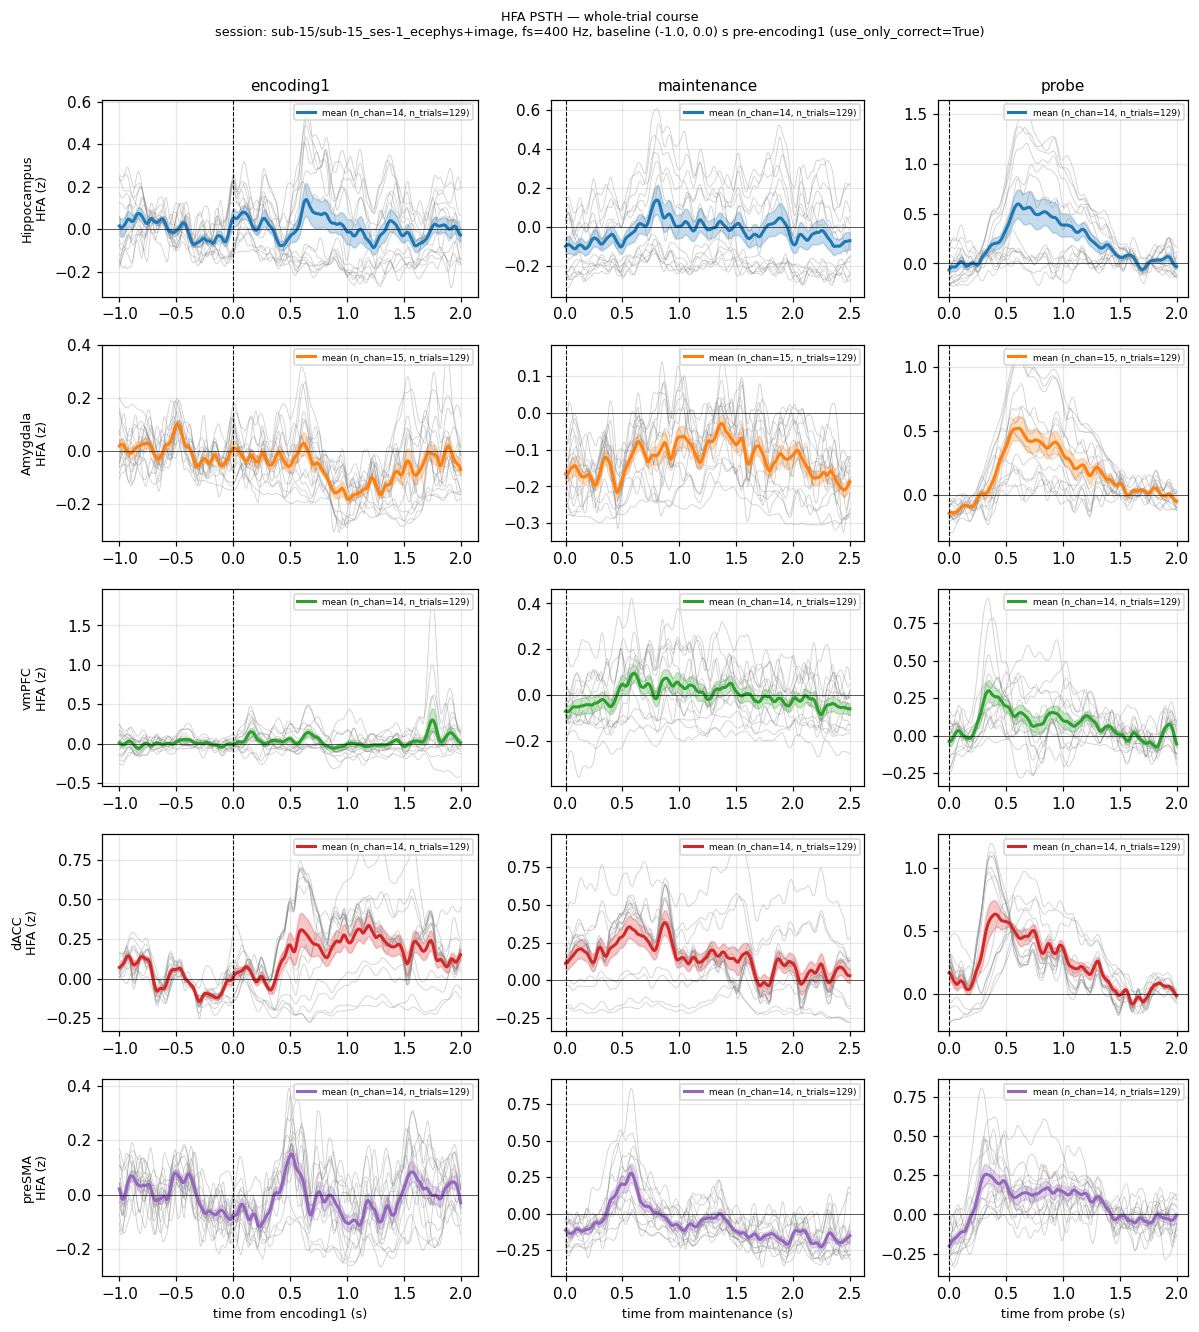

In [68]:
# Per (region, event): compute per-channel trial-mean (n_chan, n_t),
# then plot all channels as thin gray traces + bold mean across channels with SEM.

regions = CONFIG['psth_regions']
events = list(CONFIG['psth_events'])
nrows = len(regions); ncols = len(events)

# Sub-figure widths proportional to event window duration so time scaling is honest
widths = [(w[1] - w[0]) for w in CONFIG['psth_events'].values()]
fig, axes = plt.subplots(
    nrows, ncols, figsize=(11, 2.4 * nrows),
    gridspec_kw={'width_ratios': widths},
    squeeze=False,
)

palette = plt.cm.tab10.colors

for ri, region in enumerate(regions):
    chans_in_region = region_chans.get(region, [])
    chan_pos = [plotted_chans.index(c) for c in chans_in_region if c in plotted_chans]
    region_color = palette[ri % len(palette)]
    for ci, event_name in enumerate(events):
        ax = axes[ri, ci]
        tensor = event_tensors[event_name]   # (n_trials, n_chan_total, n_t)
        rel_time = event_rel_times[event_name]
        if tensor.shape[0] == 0 or len(chan_pos) == 0:
            ax.set_title(f'{event_name}\n(no data)' if ri == 0 else '', fontsize='small')
            ax.text(0.5, 0.5, 'no data', ha='center', va='center', transform=ax.transAxes, color='gray')
            continue
        sub = tensor[:, chan_pos, :]                       # (n_trials, n_chan, n_t)
        per_chan_mean = sub.mean(axis=0)                   # (n_chan, n_t) — pool trials per channel
        # thin per-channel traces
        for r in per_chan_mean:
            ax.plot(rel_time, r, color='gray', alpha=0.35, lw=0.6)
        # region mean +/- SEM across channels
        m = per_chan_mean.mean(axis=0)
        sem = scistats.sem(per_chan_mean, axis=0) if per_chan_mean.shape[0] > 1 else np.zeros_like(m)
        ax.plot(rel_time, m, color=region_color, lw=2.0,
                label=f'mean (n_chan={per_chan_mean.shape[0]}, n_trials={sub.shape[0]})')
        ax.fill_between(rel_time, m - sem, m + sem, color=region_color, alpha=0.25)
        ax.axvline(0, color='k', lw=0.7, linestyle='--')
        ax.axhline(0, color='k', lw=0.4)
        if ri == 0:
            ax.set_title(event_name, fontsize='medium')
        if ci == 0:
            ax.set_ylabel(f'{region}\nHFA (z)', fontsize='small')
        if ri == nrows - 1:
            ax.set_xlabel(f'time from {event_name} (s)', fontsize='small')
        ax.legend(loc='upper right', fontsize='xx-small')

plt.suptitle(
    f'HFA PSTH — whole-trial course\n'
    f'session: {sess["subject"]}/{sess["session"]}, fs={fs:.0f} Hz, '
    f'baseline {CONFIG["hfa_baseline_window"]} s pre-{CONFIG["hfa_baseline_lock_event"]} '
    f'(use_only_correct={CONFIG["use_only_correct"]})',
    fontsize='small', y=1.005,
)
plt.tight_layout()
out_path = OUT_DIR / f'psth_{sess["subject"]}_{sess["session"]}.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
print(f'saved -> {out_path}')
plt.show()

## 7. Save

In [69]:
# Save the per-event tensors + region channel mapping for downstream use
import pickle
out_pkl = OUT_DIR / f'psth_data_{sess["subject"]}_{sess["session"]}.pkl'
with open(out_pkl, 'wb') as f:
    pickle.dump({
        'session': f'{sess["subject"]}/{sess["session"]}',
        'fs': fs,
        'plotted_chans': plotted_chans,
        'chan_to_region': chan_to_region,
        'region_chans': {r: region_chans.get(r, []) for r in CONFIG['psth_regions']},
        'event_tensors': event_tensors,
        'event_rel_times': event_rel_times,
        'config': {k: v for k, v in CONFIG.items() if k != 'data_dir'},
    }, f)
print(f'saved -> {out_pkl}')

saved -> E:\SBCAT\outputs\hfa_psth_whole_trial\psth_data_sub-15_sub-15_ses-1_ecephys+image.pkl


## 8. All-Sessions PSTH

Loops over every session passing the dual-coverage threshold, saves a per-session
PSTH figure to disk, and accumulates per-channel trial-mean traces (per region,
per event) across sessions for the overall pooled plot below.

Set `RUN_ALL_SESSIONS = False` to skip the full sweep (e.g. when iterating on the
single-session preview above).

In [70]:
# Reusable per-session pipeline.  Returns a dict of per-channel trial-mean arrays
# per (region, event) plus session metadata. Optionally writes a figure.

def run_session_psth(filepath, cfg, rng=None, save_fig=True, show_fig=False, save_dir=None):
    rng = rng if rng is not None else np.random.default_rng(cfg['random_seed'])
    nwb = load_nwb_file(filepath)
    try:
        clean_lfp, fs, edf, _ = preprocess_session_lfp(nwb, cfg, verbose=False)
    finally:
        pass  # keep io open until we're done with trials below
    trials = nwb['trials']
    if cfg['use_only_correct'] and 'response_accuracy' in trials.columns:
        trials = trials[trials['response_accuracy'] == 1].copy()

    region_chans_local, _ = extract_region_channels(edf)
    n_chan_lfp = clean_lfp.shape[1]
    region_chans_local = {r: [c for c in region_chans_local.get(r, []) if c < n_chan_lfp]
                          for r in cfg['psth_regions']}

    plotted_chans_local = []
    for r in cfg['psth_regions']:
        for c in region_chans_local[r]:
            if c not in plotted_chans_local:
                plotted_chans_local.append(c)

    if not plotted_chans_local:
        nwb['io'].close()
        return None

    hfa_local, _ = extract_hfa_session(clean_lfp, fs, plotted_chans_local, trials, cfg, rng=rng)

    # Per-event tensors and per-channel trial-mean arrays
    event_tensors_local = {}
    event_rel_times_local = {}
    for event_name, window in cfg['psth_events'].items():
        lock_col = _LOCK_COL_MAP[event_name]
        lock_times = trials[lock_col].to_numpy()
        tensor, _, rel_time = epoch_continuous(hfa_local, fs, lock_times, window)
        event_tensors_local[event_name] = tensor
        event_rel_times_local[event_name] = rel_time

    per_channel_means = {}
    n_trials_per_event = {}
    for region in cfg['psth_regions']:
        per_channel_means[region] = {}
        chan_pos = [plotted_chans_local.index(c) for c in region_chans_local[region]]
        for event_name in cfg['psth_events']:
            tensor = event_tensors_local[event_name]
            rt = event_rel_times_local[event_name]
            if tensor.shape[0] == 0 or len(chan_pos) == 0:
                per_channel_means[region][event_name] = np.zeros((0, len(rt)))
                n_trials_per_event[event_name] = tensor.shape[0]
                continue
            sub = tensor[:, chan_pos, :]                       # (n_trials, n_chan, n_t)
            per_channel_means[region][event_name] = sub.mean(axis=0)  # (n_chan, n_t)
            n_trials_per_event[event_name] = sub.shape[0]

    out = {
        'subject': filepath.parent.name,
        'session': filepath.stem,
        'fs': fs,
        'per_channel_means': per_channel_means,
        'event_rel_times': event_rel_times_local,
        'n_trials_per_event': n_trials_per_event,
        'region_chans': region_chans_local,
    }

    if save_fig or show_fig:
        plot_psth_grid(out, cfg, save_dir=save_dir, show=show_fig)

    nwb['io'].close()
    return out


def plot_psth_grid(session_out, cfg, save_dir=None, show=True, suptitle_extra=''):
    """Plot the standard 5-region x 3-event PSTH grid from a session_out dict
    (or pooled-data dict with the same shape).
    """
    regions = cfg['psth_regions']
    events = list(cfg['psth_events'])
    nrows = len(regions); ncols = len(events)
    widths = [(w[1] - w[0]) for w in cfg['psth_events'].values()]
    fig, axes = plt.subplots(
        nrows, ncols, figsize=(11, 2.4 * nrows),
        gridspec_kw={'width_ratios': widths}, squeeze=False,
    )
    palette = plt.cm.tab10.colors
    pcm = session_out['per_channel_means']
    rt = session_out['event_rel_times']
    n_trials = session_out.get('n_trials_per_event', {})
    for ri, region in enumerate(regions):
        region_color = palette[ri % len(palette)]
        for ci, event_name in enumerate(events):
            ax = axes[ri, ci]
            curves = pcm[region][event_name]    # (n_chan, n_t)
            x = rt[event_name]
            if curves.shape[0] == 0:
                ax.text(0.5, 0.5, 'no data', ha='center', va='center',
                        transform=ax.transAxes, color='gray')
                if ri == 0:
                    ax.set_title(event_name, fontsize='medium')
                continue
            for r in curves:
                ax.plot(x, r, color='gray', alpha=0.3, lw=0.5)
            m = curves.mean(axis=0)
            sem = scistats.sem(curves, axis=0) if curves.shape[0] > 1 else np.zeros_like(m)
            n_tr = n_trials.get(event_name, '?')
            ax.plot(x, m, color=region_color, lw=2.0,
                    label=f'mean (n_chan={curves.shape[0]}, n_trials={n_tr})')
            ax.fill_between(x, m - sem, m + sem, color=region_color, alpha=0.25)
            ax.axvline(0, color='k', lw=0.7, linestyle='--')
            ax.axhline(0, color='k', lw=0.4)
            if ri == 0:
                ax.set_title(event_name, fontsize='medium')
            if ci == 0:
                ax.set_ylabel(f'{region}\nHFA (z)', fontsize='small')
            if ri == nrows - 1:
                ax.set_xlabel(f'time from {event_name} (s)', fontsize='small')
            ax.legend(loc='upper right', fontsize='xx-small')

    sub = session_out.get('subject', '?'); ses = session_out.get('session', '?')
    fs_v = session_out.get('fs', None)
    fs_str = f'{fs_v:.0f} Hz' if fs_v is not None else 'fs=?'
    plt.suptitle(
        f'HFA PSTH — {sub}/{ses}, {fs_str}, baseline {cfg["hfa_baseline_window"]} s '
        f'pre-{cfg["hfa_baseline_lock_event"]} {suptitle_extra}',
        fontsize='small', y=1.005,
    )
    plt.tight_layout()
    if save_dir is not None:
        save_dir = Path(save_dir); save_dir.mkdir(parents=True, exist_ok=True)
        out_path = save_dir / f'psth_{sub}_{ses}.png'
        plt.savefig(out_path, dpi=130, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)


print('per-session pipeline + plot helpers defined')


per-session pipeline + plot helpers defined


In [71]:
# --- All-sessions sweep (threaded compute, sequential plotting) ---
RUN_ALL_SESSIONS = True
SAVE_PER_SESSION_FIG = True
N_WORKERS = 4   # threads for compute; plotting is always serial in main thread

from concurrent.futures import ThreadPoolExecutor, as_completed

if RUN_ALL_SESSIONS:
    all_session_results = []
    skipped = []
    sessions_list = list(passing.reset_index(drop=True).iterrows())

    def _compute(sess_i, sess):
        try:
            result = run_session_psth(
                sess['filepath'], CONFIG,
                rng=np.random.default_rng(CONFIG['random_seed'] + sess_i),
                save_fig=False, show_fig=False, save_dir=None,   # compute only
            )
            return ('ok', sess_i, sess, result)
        except Exception as e:
            return ('err', sess_i, sess, repr(e))

    print(f'Compute pass: {len(sessions_list)} sessions, {N_WORKERS} threads')
    with ThreadPoolExecutor(max_workers=N_WORKERS) as exe:
        futs = [exe.submit(_compute, i, sess) for i, sess in sessions_list]
        for fut in as_completed(futs):
            status, sess_i, sess, payload = fut.result()
            tag = f"{sess['subject']}/{sess['session']}"
            if status == 'ok' and payload is not None:
                all_session_results.append(payload)
                print(f'  [done] {tag}')
            else:
                detail = payload if status == 'err' else 'no plotted channels'
                print(f'  [skip] {tag}: {detail}')
                skipped.append((sess['subject'], sess['session']))

    # Restore original session order so figures are saved in a predictable order
    order = {f"{r['subject']}/{r['session']}": i for i, (_, r) in enumerate(sessions_list)}
    all_session_results.sort(key=lambda r: order.get(f"{r['subject']}/{r['session']}", 0))

    # Plot pass — sequential, main thread (matplotlib not thread-safe)
    if SAVE_PER_SESSION_FIG:
        print(f'Plot pass: writing {len(all_session_results)} per-session figures to {OUT_DIR}')
        for r in all_session_results:
            plot_psth_grid(r, CONFIG, save_dir=OUT_DIR, show=False)

    print(f'=== sweep done: {len(all_session_results)} sessions OK, {len(skipped)} skipped ===')
    if skipped:
        print('  skipped:', skipped)
else:
    print('RUN_ALL_SESSIONS = False — using just the single-session preview above.')
    all_session_results = [{
        'subject': sess['subject'], 'session': sess['session'], 'fs': fs,
        'per_channel_means': {
            r: {e: (event_tensors[e][:, [plotted_chans.index(c) for c in region_chans.get(r, [])
                                          if c in plotted_chans], :].mean(axis=0)
                    if event_tensors[e].shape[0] and any(c in plotted_chans for c in region_chans.get(r, []))
                    else np.zeros((0, len(event_rel_times[e]))))
                for e in CONFIG['psth_events']}
            for r in CONFIG['psth_regions']
        },
        'event_rel_times': event_rel_times,
        'n_trials_per_event': {e: event_tensors[e].shape[0] for e in CONFIG['psth_events']},
    }]


Compute pass: 10 sessions, 4 threads
  [warn] LFP has 53 channels but electrodes table has 56 rows; channels with idx >= 53 will be dropped downstream
  [warn] LFP has 55 channels but electrodes table has 64 rows; channels with idx >= 55 will be dropped downstream
  [warn] LFP has 69 channels but electrodes table has 73 rows; channels with idx >= 69 will be dropped downstream
  [warn] LFP has 70 channels but electrodes table has 74 rows; channels with idx >= 70 will be dropped downstream
  [done] sub-12/sub-12_ses-1_ecephys+image
  [done] sub-12/sub-12_ses-2_ecephys+image
  [done] sub-1/sub-1_ses-2_ecephys+image
  [done] sub-1/sub-1_ses-1_ecephys+image
  [warn] LFP has 59 channels but electrodes table has 72 rows; channels with idx >= 59 will be dropped downstream
  [warn] LFP has 58 channels but electrodes table has 71 rows; channels with idx >= 58 will be dropped downstream
  [done] sub-13/sub-13_ses-1_ecephys+image
  [warn] LFP has 69 channels but electrodes table has 73 rows; chann

Pooled per-region channel counts:
  Hippocampus: 130 channels (across 10 sessions)
  Amygdala: 139 channels (across 10 sessions)
  vmPFC: 87 channels (across 10 sessions)
  dACC: 143 channels (across 10 sessions)
  preSMA: 144 channels (across 10 sessions)


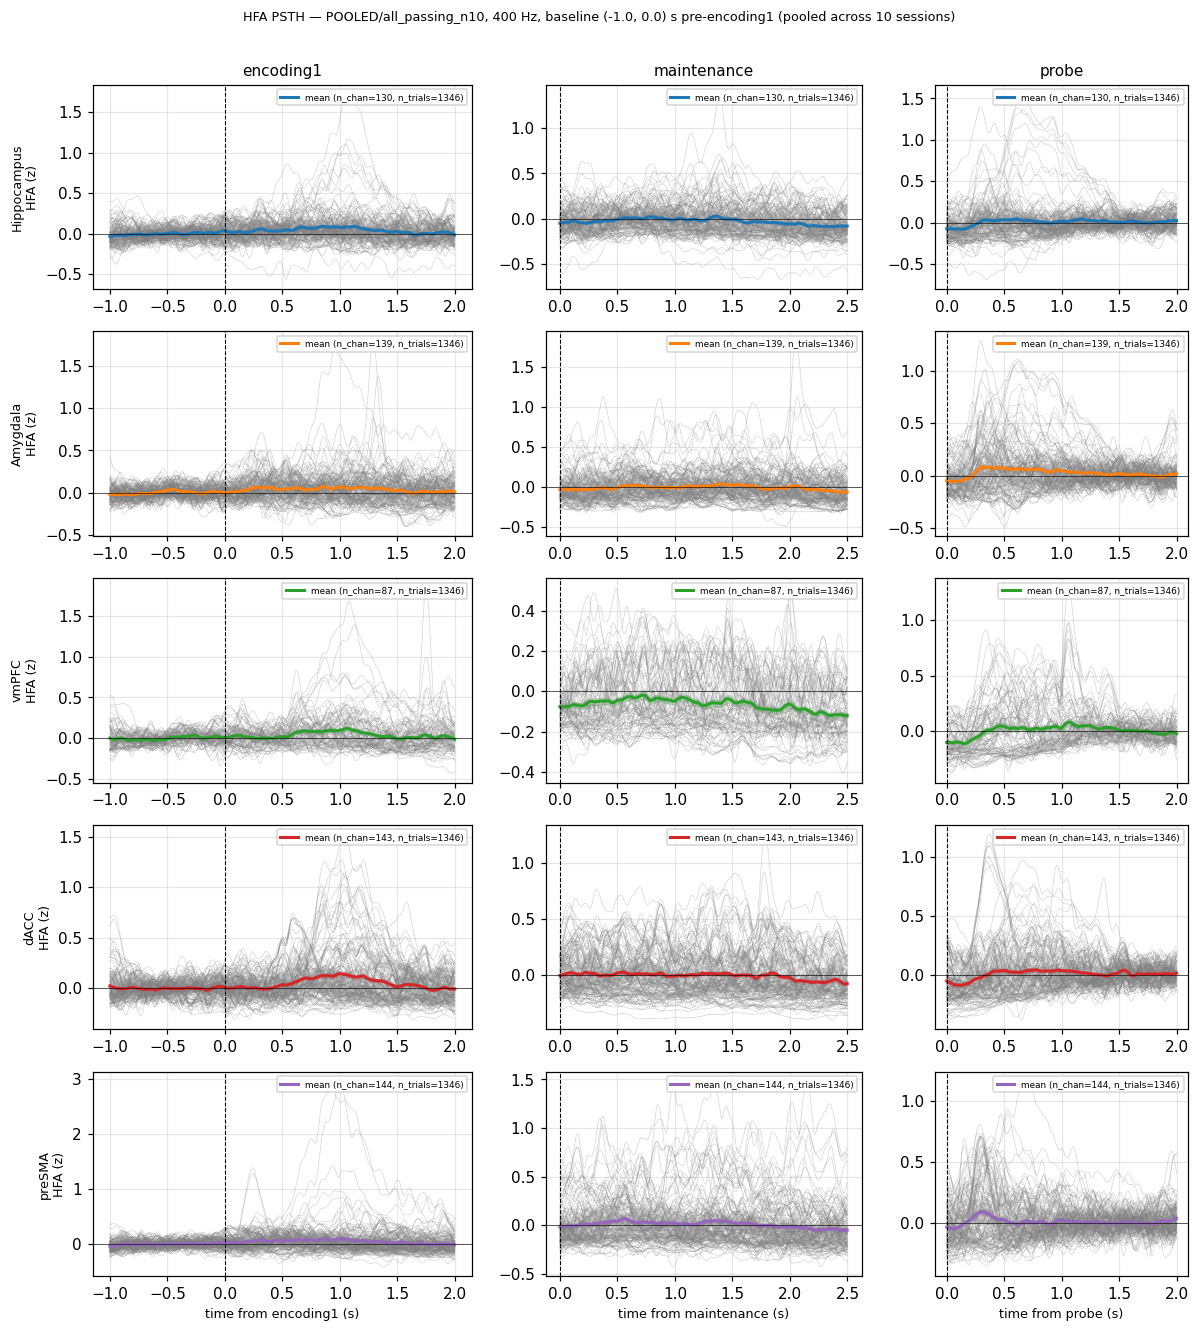


saved pooled data -> E:\SBCAT\outputs\hfa_psth_whole_trial\psth_pooled_n10.pkl


In [72]:
# --- Pooled overall PSTH: every channel from every session, per region ---
# Stack per-channel trial-mean traces across sessions (each session contributes
# one row per channel per region), then plot the same grid using the population.

if not all_session_results:
    print('No session results to pool.')
else:
    # All sessions in this dataset share fs (400 Hz) and identical event windows,
    # so rel_time is identical across sessions; just take the first one as reference.
    ref_rel_times = all_session_results[0]['event_rel_times']

    pooled_per_channel = {r: {e: [] for e in CONFIG['psth_events']} for r in CONFIG['psth_regions']}
    pooled_n_trials_total = {e: 0 for e in CONFIG['psth_events']}
    for result in all_session_results:
        for r in CONFIG['psth_regions']:
            for e in CONFIG['psth_events']:
                arr = result['per_channel_means'][r][e]
                # Sanity: verify the length matches reference rel_time
                if arr.shape[0] == 0:
                    continue
                if arr.shape[1] != len(ref_rel_times[e]):
                    print(f'  [warn] {result["subject"]}/{result["session"]} '
                          f'{r}/{e}: n_t mismatch {arr.shape[1]} vs {len(ref_rel_times[e])}; skipping')
                    continue
                pooled_per_channel[r][e].append(arr)
        for e in CONFIG['psth_events']:
            pooled_n_trials_total[e] += result['n_trials_per_event'].get(e, 0)

    pooled_stack = {
        r: {e: (np.concatenate(arrs, axis=0)
                if arrs else np.zeros((0, len(ref_rel_times[e]))))
            for e, arrs in events.items()}
        for r, events in pooled_per_channel.items()
    }

    print('Pooled per-region channel counts:')
    for r in CONFIG['psth_regions']:
        n = pooled_stack[r][list(CONFIG['psth_events'])[0]].shape[0]
        print(f'  {r}: {n} channels (across {len(all_session_results)} sessions)')

    pooled_out = {
        'subject': 'POOLED',
        'session': f'all_passing_n{len(all_session_results)}',
        'fs': all_session_results[0]['fs'],
        'per_channel_means': pooled_stack,
        'event_rel_times': ref_rel_times,
        'n_trials_per_event': pooled_n_trials_total,
    }
    plot_psth_grid(
        pooled_out, CONFIG,
        save_dir=OUT_DIR, show=True,
        suptitle_extra=f'(pooled across {len(all_session_results)} sessions)',
    )

    # Save pooled tensor for downstream use
    import pickle
    out_pkl = OUT_DIR / f'psth_pooled_n{len(all_session_results)}.pkl'
    with open(out_pkl, 'wb') as f:
        pickle.dump({
            'config': {k: v for k, v in CONFIG.items() if k != 'data_dir'},
            'pooled': pooled_stack,
            'rel_times': ref_rel_times,
            'n_sessions': len(all_session_results),
            'session_meta': [{'subject': r['subject'], 'session': r['session']} for r in all_session_results],
        }, f)
    print(f'\nsaved pooled data -> {out_pkl}')
